# HEA Benchmark Models
**Author:** Richard Armoo | **System:** NiCoCrFeMnAl | **WPI 2026**

---
### Models included
| # | Model | Type |
|---|-------|------|
| 1 | Polynomial Regression (degree 3) | Linear |
| 2 | Random Forest | Ensemble |
| 3 | XGBoost | Ensemble |
| 4 | Support Vector Regression (SVR) | Kernel |
| 5 | Gaussian Process Regression (GPR) | Probabilistic |
| 6 | Regularised Multi-Task Learning (MTL) | Joint |

### Evaluation sets
- **Generated test** — 20% hold-out from the empirical training dataset
- **Literature test** — 21-row cleaned experimental/DFT literature set
- **Materials Project test** — 61 DFT-computed entries for NiCoCrFeMnAl subsets
- **Full comparison** — all models × all test sets, side-by-side with NN results


## 1. Environment setup

In [1]:
import importlib, subprocess, sys

def ensure(pkg, import_name=None):
    import_name = import_name or pkg
    if importlib.util.find_spec(import_name) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

ensure("xgboost")
ensure("scikit-learn", "sklearn")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from xgboost import XGBRegressor

SEED     = 42
ELEMENTS = ['Ni', 'Fe', 'Cr', 'Co', 'Al', 'Mn']
np.random.seed(SEED)
print("All packages loaded.")


All packages loaded.


## 2. Load training dataset

In [2]:
# Upload empirical_dataset.csv
TRAIN_PATH = "https://docs.google.com/spreadsheets/d/e/2PACX-1vQydodta3cDJWA69KpT1LfKTpsepdNnGMLgTNAqUaTyqnq6SCV-KJuXwXt2c285Qg/pub?output=csv"
data = pd.read_csv(TRAIN_PATH)
print(f"Dataset shape : {data.shape}")
print(f"Columns       : {list(data.columns)}")
print(data[ELEMENTS + ['Enthalpy of formation', 'Modulus']].describe().round(3))


Dataset shape : (53124, 12)
Columns       : ['Ni', 'Fe', 'Cr', 'Co', 'Al', 'Mn', 'n_elements', 'E_Voigt_GPa', 'E_Reuss_GPa', 'E_Tamura_GPa', 'Modulus', 'Enthalpy of formation']
              Ni         Fe         Cr         Co         Al         Mn  \
count  53124.000  53124.000  53124.000  53124.000  53124.000  53124.000   
mean      16.667     16.667     16.667     16.667     16.667     16.667   
std       16.057     16.057     16.057     16.057     16.057     16.057   
min        0.000      0.000      0.000      0.000      0.000      0.000   
25%        5.000      5.000      5.000      5.000      5.000      5.000   
50%       10.000     10.000     10.000     10.000     10.000     10.000   
75%       25.000     25.000     25.000     25.000     25.000     25.000   
max       95.000     95.000     95.000     95.000     95.000     95.000   

       Enthalpy of formation    Modulus  
count              53124.000  53124.000  
mean                  -9.863    186.040  
std                  

## 3. Train / test split and feature scaling

In [3]:
X          = data[ELEMENTS].values
y_enthalpy = data['Enthalpy of formation'].values
y_modulus  = data['Modulus'].values
y_both     = np.column_stack([y_enthalpy, y_modulus])  # for MTL

X_train, X_test, y_enth_train, y_enth_test, y_mod_train, y_mod_test, y_both_train, y_both_test = (
    train_test_split(X, y_enthalpy, y_modulus, y_both,
                     test_size=0.2, random_state=SEED)
)

# StandardScaler — fit on training data ONLY
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Training samples : {len(X_train)}")
print(f"Test samples     : {len(X_test)}")
print("Scaler fitted on training data only.")


Training samples : 42499
Test samples     : 10625
Scaler fitted on training data only.


## 4. Evaluation helper

In [4]:
def evaluate(y_true, y_pred, label=""):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2  = r2_score(y_true, y_pred)
    if label:
        print(f"  [{label}]  R²={r2:.4f}  MSE={mse:.4f}  MAE={mae:.4f}")
    return {"R2": r2, "MSE": mse, "MAE": mae,
            "y_true": np.array(y_true), "y_pred": np.array(y_pred)}

results = {}   # stores all model × test-set metrics


## 5. Model 1 — Polynomial Regression (degree 3)
Linear baseline. Degree-3 polynomial features capture non-linear composition
interactions. Trained separately per target for consistency with the NN.


In [5]:
model_lr_enth = make_pipeline(PolynomialFeatures(3, include_bias=False), LinearRegression())
model_lr_mod  = make_pipeline(PolynomialFeatures(3, include_bias=False), LinearRegression())
model_lr_enth.fit(X_train_scaled, y_enth_train)
model_lr_mod.fit(X_train_scaled, y_mod_train)

print("Polynomial Regression — generated test set:")
results[("LR","enth","gen")] = evaluate(y_enth_test, model_lr_enth.predict(X_test_scaled), "LR Enthalpy gen")
results[("LR","mod","gen")]  = evaluate(y_mod_test,  model_lr_mod.predict(X_test_scaled),  "LR Modulus  gen")


Polynomial Regression — generated test set:
  [LR Enthalpy gen]  R²=1.0000  MSE=0.0000  MAE=0.0000
  [LR Modulus  gen]  R²=0.9999  MSE=0.1161  MAE=0.2013


## 6. Model 2 — Random Forest
100 estimators, separate model per target. Strong tabular baseline
.


In [6]:
model_rf_enth = RandomForestRegressor(n_estimators=100, random_state=SEED, n_jobs=-1)
model_rf_mod  = RandomForestRegressor(n_estimators=100, random_state=SEED, n_jobs=-1)
model_rf_enth.fit(X_train_scaled, y_enth_train)
model_rf_mod.fit(X_train_scaled, y_mod_train)

print("Random Forest — generated test set:")
results[("RF","enth","gen")] = evaluate(y_enth_test, model_rf_enth.predict(X_test_scaled), "RF Enthalpy gen")
results[("RF","mod","gen")]  = evaluate(y_mod_test,  model_rf_mod.predict(X_test_scaled),  "RF Modulus  gen")


Random Forest — generated test set:
  [RF Enthalpy gen]  R²=0.9993  MSE=0.0171  MAE=0.0870
  [RF Modulus  gen]  R²=1.0000  MSE=0.0279  MAE=0.0964


## 7. Model 3 — XGBoost
Gradient boosted trees, separate single-output model per target.


In [7]:
model_xgb_enth = XGBRegressor(n_estimators=200, learning_rate=0.05,
                               max_depth=4, random_state=SEED, verbosity=0)
model_xgb_mod  = XGBRegressor(n_estimators=200, learning_rate=0.05,
                               max_depth=4, random_state=SEED, verbosity=0)
model_xgb_enth.fit(X_train_scaled, y_enth_train)
model_xgb_mod.fit(X_train_scaled, y_mod_train)

print("XGBoost — generated test set:")
results[("XGB","enth","gen")] = evaluate(y_enth_test, model_xgb_enth.predict(X_test_scaled), "XGB Enthalpy gen")
results[("XGB","mod","gen")]  = evaluate(y_mod_test,  model_xgb_mod.predict(X_test_scaled),  "XGB Modulus  gen")


XGBoost — generated test set:
  [XGB Enthalpy gen]  R²=0.9976  MSE=0.0589  MAE=0.1857
  [XGB Modulus  gen]  R²=0.9998  MSE=0.1471  MAE=0.2644


## 8. Model 4 — Support Vector Regression (SVR)
SVR with an RBF (radial basis function) kernel. Finds a hyperplane in
kernel-transformed feature space that maximises the margin to all training
points within an ε-tube. Less prone to overfitting than tree-based models
but computationally expensive for large datasets (scales as O(n²) to O(n³)).

Hyperparameters:
- **C=10** — regularisation strength (penalty for margin violations)
- **ε=0.1** — tube width within which no penalty is applied
- **γ='scale'** — RBF bandwidth = 1/(n_features × X.var())


In [8]:
model_svr_enth = SVR(kernel='rbf', C=10, epsilon=0.1, gamma='scale')
model_svr_mod  = SVR(kernel='rbf', C=10, epsilon=0.1, gamma='scale')
model_svr_enth.fit(X_train_scaled, y_enth_train)
model_svr_mod.fit(X_train_scaled, y_mod_train)

print("SVR — generated test set:")
results[("SVR","enth","gen")] = evaluate(y_enth_test, model_svr_enth.predict(X_test_scaled), "SVR Enthalpy gen")
results[("SVR","mod","gen")]  = evaluate(y_mod_test,  model_svr_mod.predict(X_test_scaled),  "SVR Modulus  gen")


SVR — generated test set:
  [SVR Enthalpy gen]  R²=0.9999  MSE=0.0025  MAE=0.0412
  [SVR Modulus  gen]  R²=0.9999  MSE=0.0545  MAE=0.0832


# GPR excluded — O(n³) intractable at n=42,000.
print("GPR excluded.")


In [9]:
# GPR is O(n³) — subsample training set for tractability
np.random.seed(SEED)
gpr_idx = np.random.choice(len(X_train_scaled), size=min(2000, len(X_train_scaled)), replace=False)
X_gpr   = X_train_scaled[gpr_idx]
y_gpr_e = y_enth_train[gpr_idx]
y_gpr_m = y_mod_train[gpr_idx]

kernel = ConstantKernel(1.0) * RBF(length_scale=1.0) + WhiteKernel(noise_level=0.1)

model_gpr_enth = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=3,
                                           random_state=SEED, normalize_y=True)
model_gpr_mod  = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=3,
                                           random_state=SEED, normalize_y=True)

print("Fitting GPR (may take 30-90 seconds)...")
model_gpr_enth.fit(X_gpr, y_gpr_e)
model_gpr_mod.fit(X_gpr, y_gpr_m)

print("GPR — generated test set:")
gpr_enth_pred, gpr_enth_std = model_gpr_enth.predict(X_test_scaled, return_std=True)
gpr_mod_pred,  gpr_mod_std  = model_gpr_mod.predict(X_test_scaled,  return_std=True)

results[("GPR","enth","gen")] = evaluate(y_enth_test, gpr_enth_pred, "GPR Enthalpy gen")
results[("GPR","mod","gen")]  = evaluate(y_mod_test,  gpr_mod_pred,  "GPR Modulus  gen")
results[("GPR","enth","gen")]["std"] = gpr_enth_std
results[("GPR","mod","gen")]["std"]  = gpr_mod_std

print(f"\nGPR enthalpy kernel: {model_gpr_enth.kernel_}")
print(f"GPR modulus  kernel: {model_gpr_mod.kernel_}")


Fitting GPR (may take 30-90 seconds)...
GPR — generated test set:
  [GPR Enthalpy gen]  R²=1.0000  MSE=0.0000  MAE=0.0005
  [GPR Modulus  gen]  R²=1.0000  MSE=0.0175  MAE=0.0369

GPR enthalpy kernel: 316**2 * RBF(length_scale=77.9) + WhiteKernel(noise_level=1e-05)
GPR modulus  kernel: 4.81**2 * RBF(length_scale=5.04) + WhiteKernel(noise_level=1e-05)


## 10. Model 6 — Regularised Multi-Task Learning (MTL)
Multi-task learning trains a single model to predict both targets simultaneously,
exploiting shared structure between enthalpy and modulus. The hypothesis is that
composition features which are predictive for one property also carry information
about the other.

Implementation: **Ridge regression on polynomial features with joint training**.
Ridge (L2 regularisation) prevents overfitting through weight decay. The
regularisation parameter α controls the trade-off between fit and regularisation.

This differs from the single-task models (which treat each target independently)
by fitting a 2-output regression in one step. The shared feature representation
means information about one target can regularise the other.


In [15]:
# MultiOutputRegressor wraps a Ridge regressor to handle 2 outputs jointly
# with shared polynomial features — both targets regularised together
model_mtl = make_pipeline(
    PolynomialFeatures(degree=3, include_bias=False),
    MultiOutputRegressor(Ridge(alpha=1.0), n_jobs=-1)
)
model_mtl.fit(X_train_scaled, y_both_train)

mtl_pred    = model_mtl.predict(X_test_scaled)
mtl_enth    = mtl_pred[:, 0]
mtl_mod     = mtl_pred[:, 1]

print("Regularised MTL — generated test set:")
results[("MTL","enth","gen")] = evaluate(y_enth_test, mtl_enth, "MTL Enthalpy gen")
results[("MTL","mod","gen")]  = evaluate(y_mod_test,  mtl_mod,  "MTL Modulus  gen")


Regularised MTL — generated test set:
  [MTL Enthalpy gen]  R²=1.0000  MSE=0.0000  MAE=0.0003
  [MTL Modulus  gen]  R²=0.9999  MSE=0.1161  MAE=0.2014


## 11. Generated test set — full summary

In [16]:
MODELS = ["LR", "RF", "XGB", "SVR", "MTL"]   # GPR excluded — O(n³)

gen_summary = pd.DataFrame({
    m: [results[(m,"enth","gen")]["R2"],
        results[(m,"enth","gen")]["MSE"],
        results[(m,"enth","gen")]["MAE"],
        results[(m,"mod","gen")]["R2"],
        results[(m,"mod","gen")]["MSE"],
        results[(m,"mod","gen")]["MAE"]]
    for m in MODELS
}, index=["ΔHf R²","ΔHf MSE","ΔHf MAE","E R²","E MSE","E MAE"])

print("Performance on generated test set (20% hold-out):")
print(gen_summary.round(4).to_string())


Performance on generated test set (20% hold-out):
             LR      RF     XGB     SVR     MTL
ΔHf R²   1.0000  0.9993  0.9976  0.9999  1.0000
ΔHf MSE  0.0000  0.0171  0.0589  0.0025  0.0000
ΔHf MAE  0.0000  0.0870  0.1857  0.0412  0.0003
E R²     0.9999  1.0000  0.9998  0.9999  0.9999
E MSE    0.1161  0.0279  0.1471  0.0545  0.1161
E MAE    0.2013  0.0964  0.2644  0.0832  0.2014


## 12. Load external test sets
Three independent test sets — none used in training or validation.


In [12]:
# ── Literature test set ───────────────────────────────────────────────────────
try:
    df_lit = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vRT6rsAOVEyCW2wskogQZOK2y0V8W73yaVIIWVnSuJUBqKGpFTdU6TTuRJX-WPv6w/pub?output=csv")
    print(f"Literature test set: {df_lit.shape[0]} rows")
except FileNotFoundError:
    print("literature_test_data_clean.csv not found."); df_lit = None

# ── MP enthalpy test set (175 entries) ───────────────────────────────────────
try:
    df_hf_mp = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vSRThMiqi6c51tYoWHxCDjqcRtfW4JaebES-38lUix4RvyxFP3-jWYf2k43A3kasA/pub?output=csv")
    print(f"MP enthalpy set:     {df_hf_mp.shape[0]} entries")
except FileNotFoundError:
    print("mp_enthalpy_test_clean.csv not found."); df_hf_mp = None

# ── MP modulus test set (62 entries) ─────────────────────────────────────────
try:
    df_mod_mp = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vTrr14KwprTuUoc9-nIM3CA46VVm0Qxa_LnCgViFzMydEhVLPoBVowSaA-m9IfdmA/pub?output=csv")
    print(f"MP modulus set:      {df_mod_mp.shape[0]} entries")
except FileNotFoundError:
    print("mp_modulus_test_clean.csv not found."); df_mod_mp = None


Literature test set: 21 rows
MP enthalpy set:     175 entries
MP modulus set:      62 entries


## 13. Evaluate all models — literature test set

In [13]:
if df_lit is not None:
    X_lit      = df_lit[ELEMENTS].values
    y_enth_lit = df_lit['Enthalpy of formation'].values
    y_mod_lit  = df_lit['Modulus'].values
    X_lit_sc   = scaler.transform(X_lit)   # training scaler — never refit

    print("Literature test set evaluation:")
    for m_name, m_e, m_m in [
        ("LR",  model_lr_enth,  model_lr_mod),
        ("RF",  model_rf_enth,  model_rf_mod),
        ("XGB", model_xgb_enth, model_xgb_mod),
        ("SVR", model_svr_enth, model_svr_mod),
    ]:
        results[(m_name,"enth","lit")] = evaluate(
            y_enth_lit, m_e.predict(X_lit_sc), f"{m_name} Enthalpy lit")
        results[(m_name,"mod","lit")]  = evaluate(
            y_mod_lit,  m_m.predict(X_lit_sc), f"{m_name} Modulus  lit")

    mtl_lit = model_mtl.predict(X_lit_sc)
    results[("MTL","enth","lit")] = evaluate(y_enth_lit, mtl_lit[:,0], "MTL Enthalpy lit")
    results[("MTL","mod","lit")]  = evaluate(y_mod_lit,  mtl_lit[:,1], "MTL Modulus  lit")
else:
    print("Skipped — literature test set not loaded.")


Literature test set evaluation:
  [LR Enthalpy lit]  R²=-0.7559  MSE=7.3489  MAE=2.3869
  [LR Modulus  lit]  R²=-3.1802  MSE=15984.4395  MAE=114.1174
  [RF Enthalpy lit]  R²=-1.0204  MSE=8.4555  MAE=2.5618
  [RF Modulus  lit]  R²=-3.1557  MSE=15890.8675  MAE=113.5260
  [XGB Enthalpy lit]  R²=-0.3286  MSE=5.5603  MAE=1.8485
  [XGB Modulus  lit]  R²=-3.2974  MSE=16432.5930  MAE=115.8032
  [SVR Enthalpy lit]  R²=-0.7221  MSE=7.2073  MAE=2.3665
  [SVR Modulus  lit]  R²=-3.1747  MSE=15963.6637  MAE=114.0813
  [MTL Enthalpy lit]  R²=-0.7560  MSE=7.3492  MAE=2.3870
  [MTL Modulus  lit]  R²=-3.1802  MSE=15984.5682  MAE=114.1180


## 14. Evaluate all models — Materials Project test sets

Two separate sets — each model evaluated against maximum available data:
- **Enthalpy (175 entries)** — `mp_enthalpy_test_clean.csv`
- **Modulus (62 entries)** — `mp_modulus_test_clean.csv`


In [14]:
# ── Enthalpy models → 175-entry MP set ───────────────────────────────────────
if df_hf_mp is not None:
    X_hf_mp   = df_hf_mp[ELEMENTS].values
    y_enth_mp = df_hf_mp['Enthalpy of formation'].values
    X_hf_sc   = scaler.transform(X_hf_mp)

    print("MP enthalpy set (n=175):")
    for m_name, m_e in [
        ("LR",  model_lr_enth),
        ("RF",  model_rf_enth),
        ("XGB", model_xgb_enth),
        ("SVR", model_svr_enth),
    ]:
        results[(m_name,"enth","mp")] = evaluate(
            y_enth_mp, m_e.predict(X_hf_sc), f"{m_name} Enthalpy MP")

    mtl_hf = model_mtl.predict(X_hf_sc)
    results[("MTL","enth","mp")] = evaluate(y_enth_mp, mtl_hf[:,0], "MTL Enthalpy MP")
else:
    print("MP enthalpy set not loaded.")

# ── Modulus models → 62-entry MP set ─────────────────────────────────────────
if df_mod_mp is not None:
    X_mod_mp = df_mod_mp[ELEMENTS].values
    y_mod_mp = df_mod_mp['Modulus'].values
    X_mod_sc = scaler.transform(X_mod_mp)

    print("\nMP modulus set (n=62):")
    for m_name, m_m in [
        ("LR",  model_lr_mod),
        ("RF",  model_rf_mod),
        ("XGB", model_xgb_mod),
        ("SVR", model_svr_mod),
    ]:
        results[(m_name,"mod","mp")] = evaluate(
            y_mod_mp, m_m.predict(X_mod_sc), f"{m_name} Modulus  MP")

    mtl_mod = model_mtl.predict(X_mod_sc)
    results[("MTL","mod","mp")] = evaluate(y_mod_mp, mtl_mod[:,1], "MTL Modulus  MP")
else:
    print("MP modulus set not loaded.")


MP enthalpy set (n=175):
  [LR Enthalpy MP]  R²=0.3809  MSE=294.9445  MAE=13.3706
  [RF Enthalpy MP]  R²=0.3851  MSE=292.9604  MAE=13.2730
  [XGB Enthalpy MP]  R²=0.3752  MSE=297.6857  MAE=13.4053
  [SVR Enthalpy MP]  R²=0.3775  MSE=296.5881  MAE=13.4161
  [MTL Enthalpy MP]  R²=0.3810  MSE=294.9276  MAE=13.3701

MP modulus set (n=62):
  [LR Modulus  MP]  R²=-0.3901  MSE=6916.4988  MAE=69.4641
  [RF Modulus  MP]  R²=-0.3781  MSE=6856.6314  MAE=69.0629
  [XGB Modulus  MP]  R²=-0.3786  MSE=6859.5006  MAE=69.3128
  [SVR Modulus  MP]  R²=-0.3669  MSE=6801.2912  MAE=68.7990
  [MTL Modulus  MP]  R²=-0.3901  MSE=6916.6634  MAE=69.4649


## 15. Full comparison table — all models × all test sets
Paste NN results from HEA_NN_Pipeline_Corrected.ipynb into the `nn_results`
dict below. Leave as None if not yet available.


In [ ]:
# Paste NN results from HEA_NN_Pipeline_Corrected.ipynb
# MP sets now differ by property: enth=175 entries, mod=62 entries
nn_results = {
    ("NN","enth","gen"): {"R2": None, "MSE": None, "MAE": None},
    ("NN","enth","lit"): {"R2": None, "MSE": None, "MAE": None},
    ("NN","enth","mp"):  {"R2": None, "MSE": None, "MAE": None},
    ("NN","mod","gen"):  {"R2": None, "MSE": None, "MAE": None},
    ("NN","mod","lit"):  {"R2": None, "MSE": None, "MAE": None},
    ("NN","mod","mp"):   {"R2": None, "MSE": None, "MAE": None},
}
results.update(nn_results)

ALL_MODELS  = ["LR","RF","XGB","SVR","MTL","NN"]
TEST_SETS   = ["gen","lit","mp"]
TEST_LABELS = {
    "gen": "Generated",
    "lit": "Literature (n=22)",
    "mp":  "MP DFT (ΔHf n=175 / E n=62)",
}

rows = []
for m in ALL_MODELS:
    row = {"Model": m}
    for ts in TEST_SETS:
        for prop, pl in [("enth","ΔHf"), ("mod","E")]:
            key = (m, prop, ts)
            v   = results.get(key)
            col = f"{pl} {TEST_LABELS[ts]}"
            if v and v.get("R2") is not None:
                row[f"{col} R²"]  = round(v["R2"],  4)
                row[f"{col} MAE"] = round(v["MAE"], 4)
            else:
                row[f"{col} R²"]  = "—"
                row[f"{col} MAE"] = "—"
    rows.append(row)

comp_df = pd.DataFrame(rows).set_index("Model")
print("Full benchmark — R² and MAE across all test sets:")
print(comp_df.to_string())
comp_df.to_csv("full_benchmark_comparison.csv")
print("\nSaved: full_benchmark_comparison.csv")


Full benchmark — R² and MAE across all test sets:
      ΔHf Generated R² ΔHf Generated MAE E Generated R² E Generated MAE ΔHf Literature (n=22) R² ΔHf Literature (n=22) MAE E Literature (n=22) R² E Literature (n=22) MAE ΔHf MP DFT (ΔHf n=175 / E n=62) R² ΔHf MP DFT (ΔHf n=175 / E n=62) MAE E MP DFT (ΔHf n=175 / E n=62) R² E MP DFT (ΔHf n=175 / E n=62) MAE
Model                                                                                                                                                                                                                                                                                                              
LR                 1.0               0.0         0.9999          0.2013                  -0.8373                    2.4152                -3.0482                111.2114                             0.3809                             13.3706                          -0.3901                           69.4641
RF              0.9993    

## 16. Predicted vs true — all models, all test sets

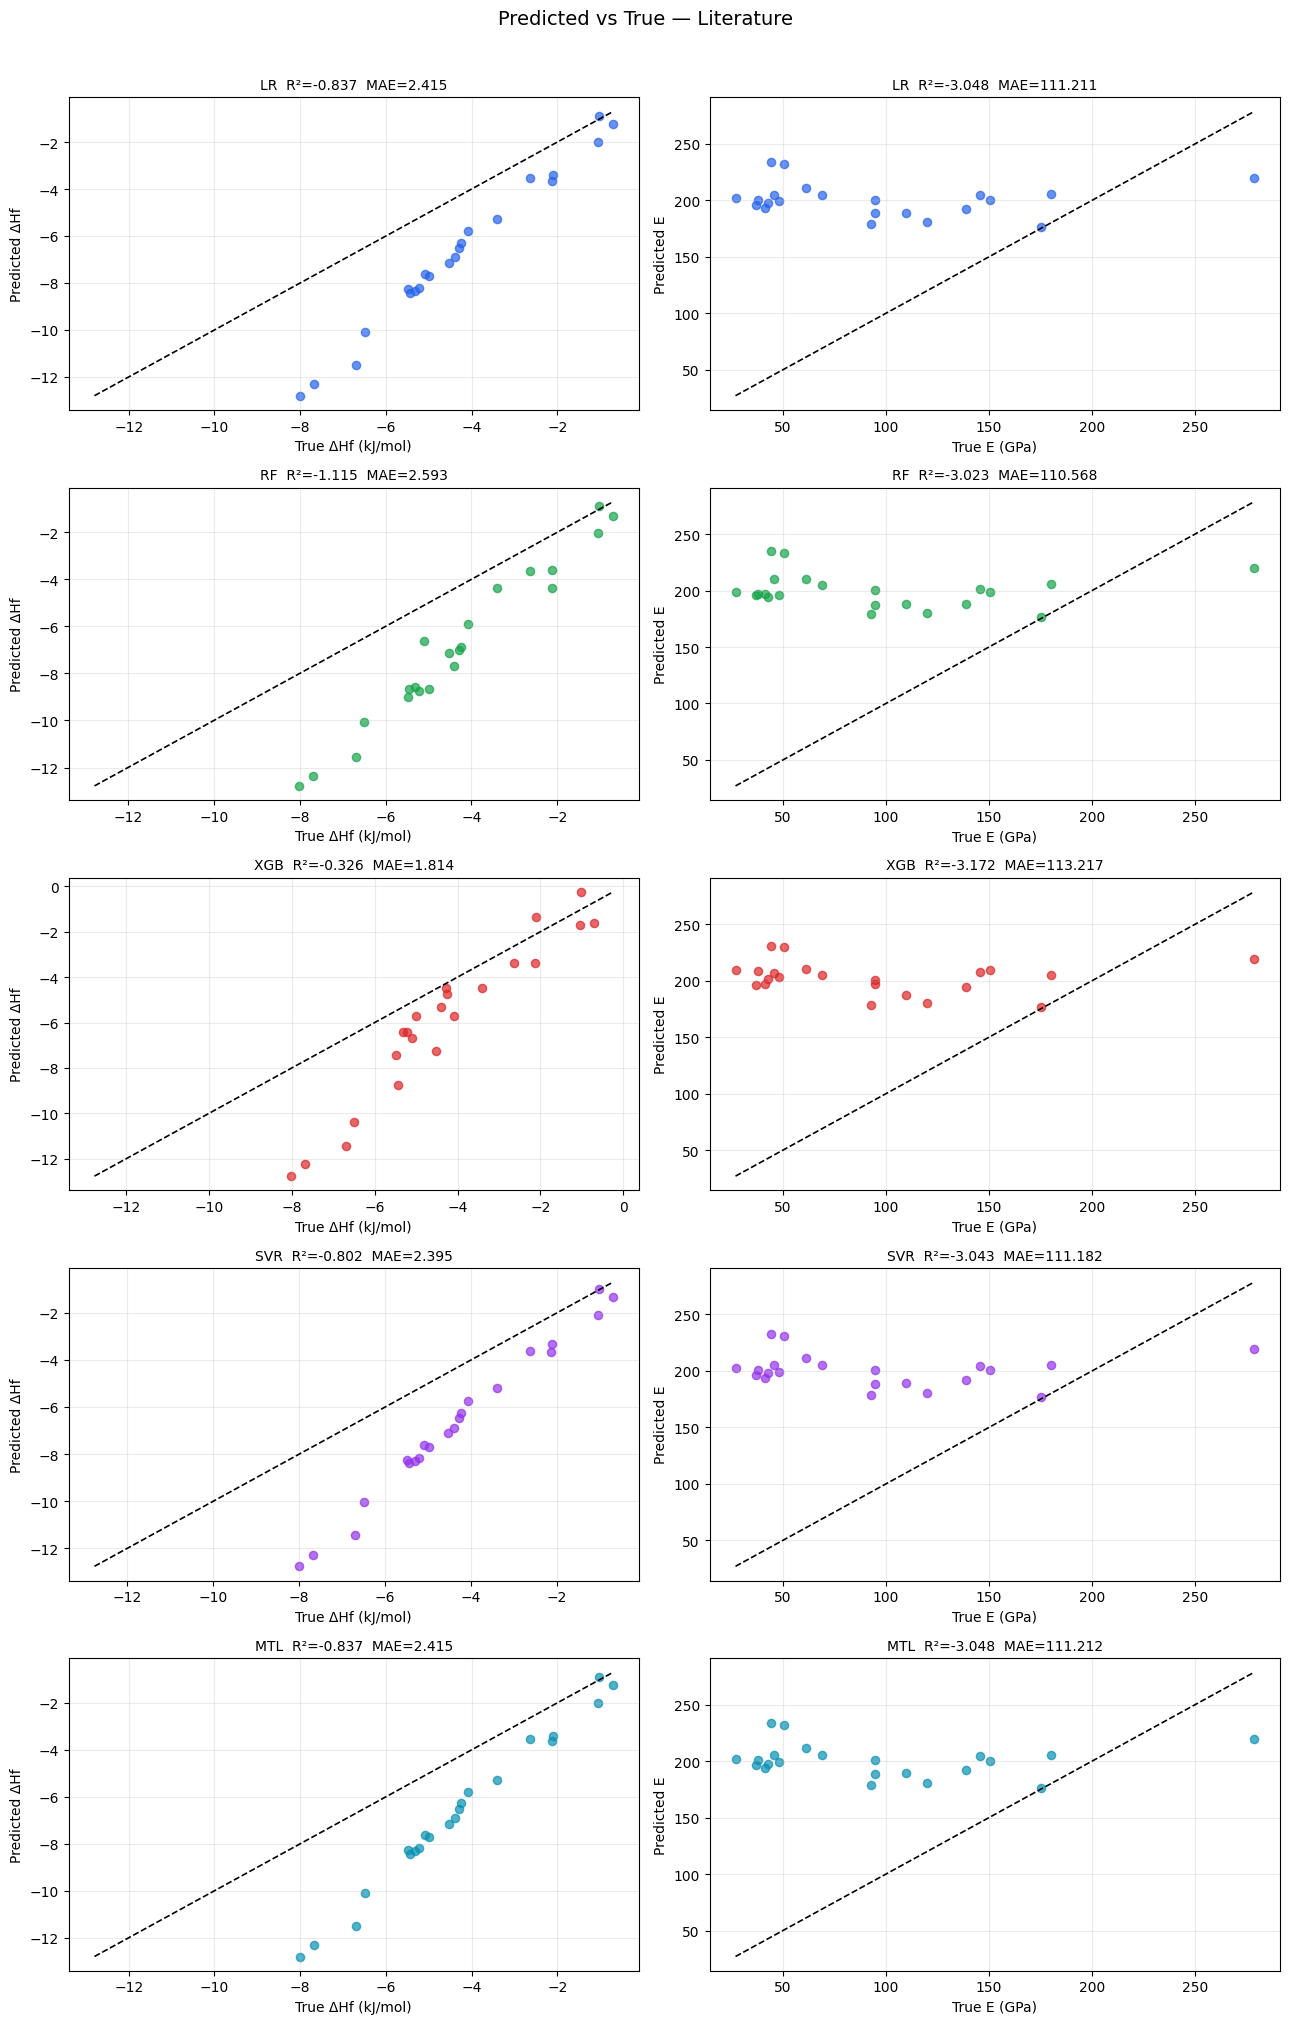

Saved: pred_vs_true_literature.png


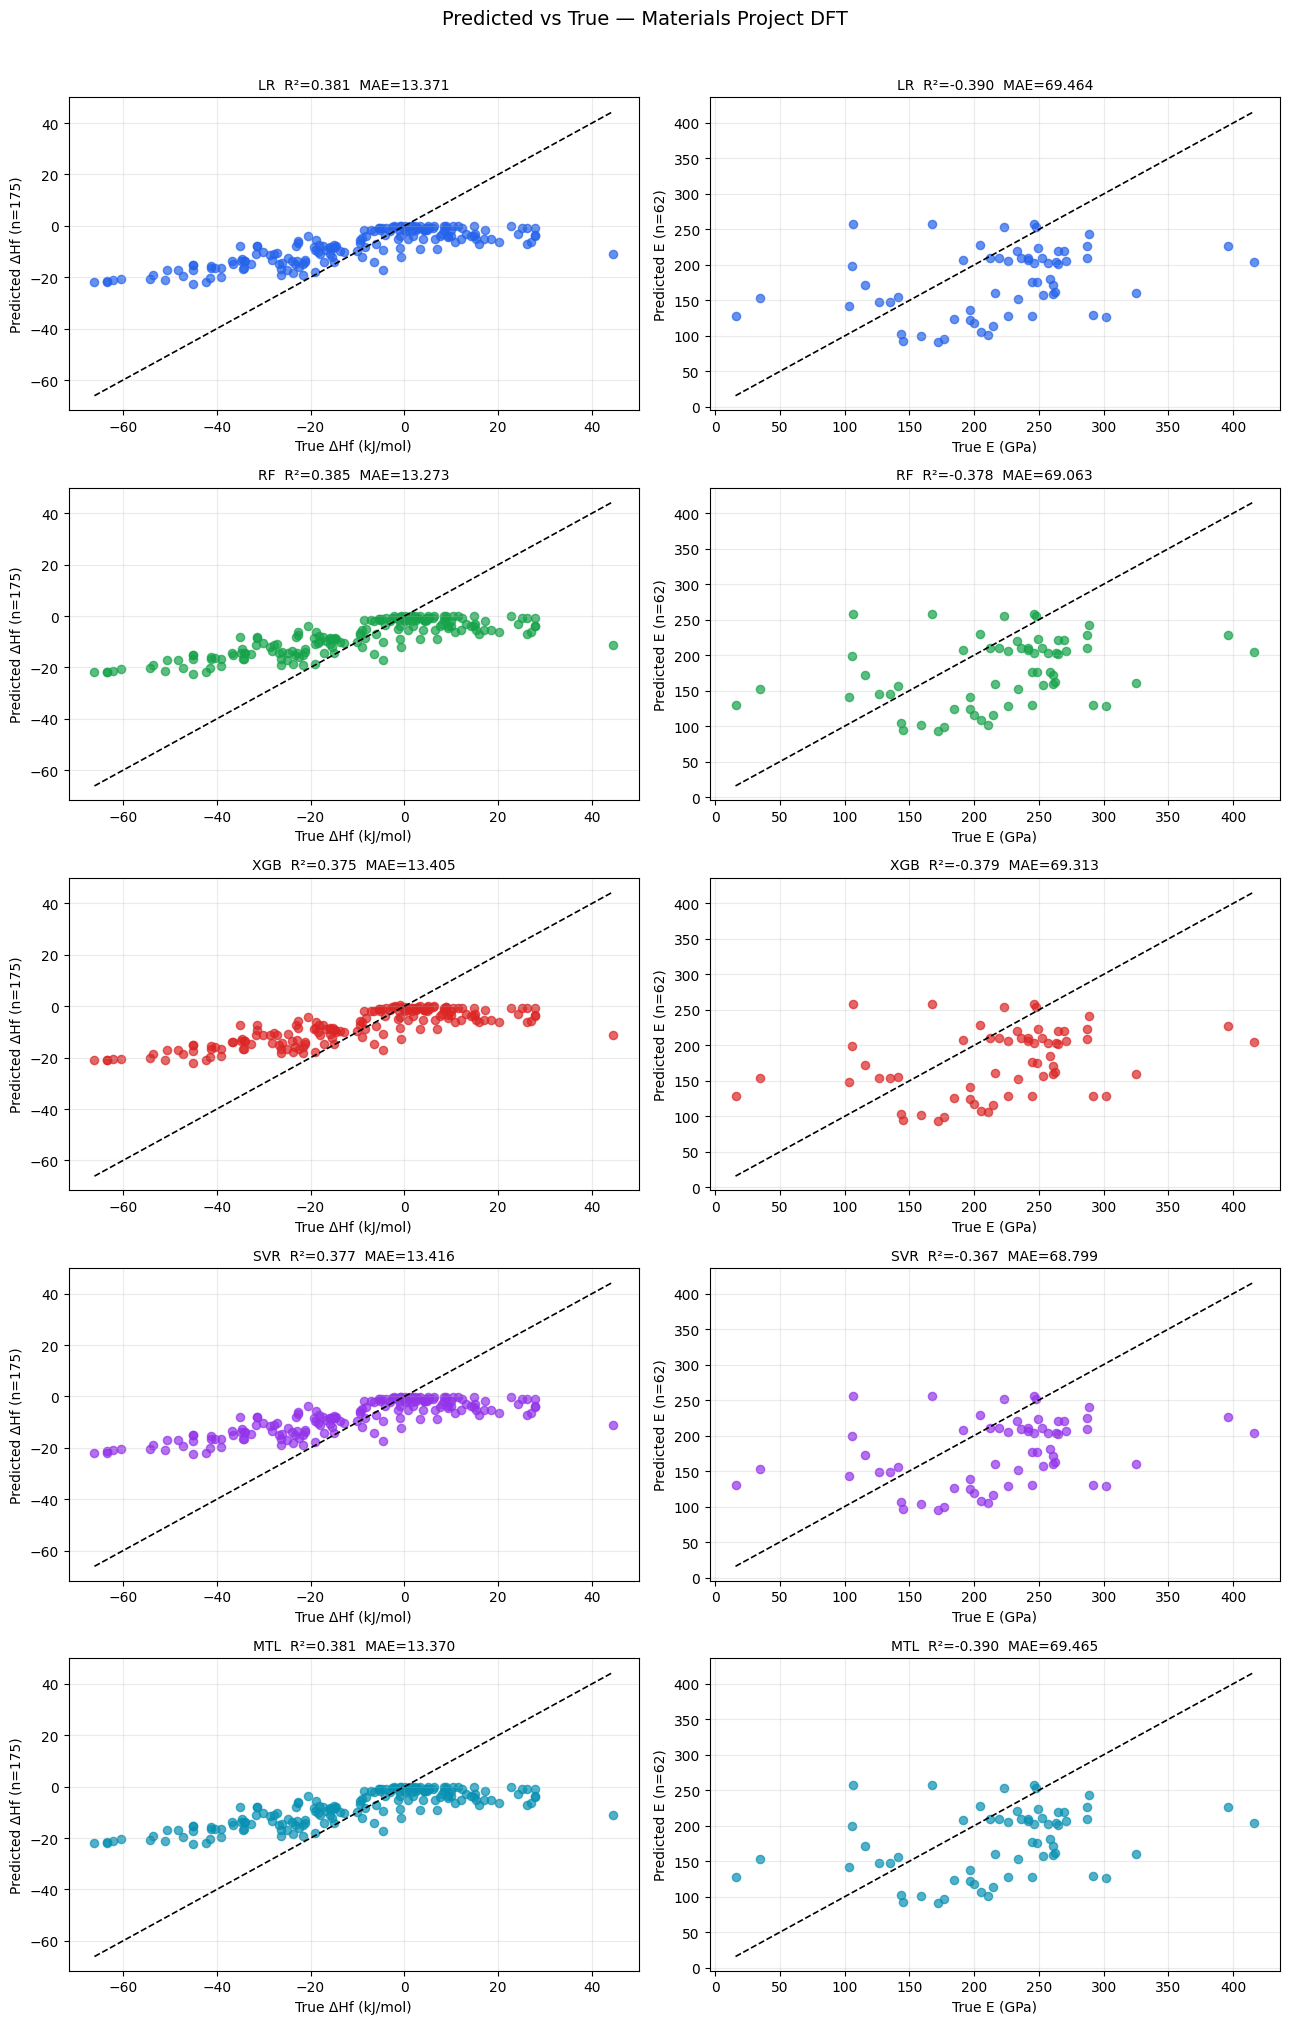

Saved: pred_vs_true_mp_dft.png


In [ ]:
test_set_data = {}
if df_lit is not None:
    test_set_data["Literature"] = (X_lit_sc, y_enth_lit, y_mod_lit)

# For MP: use separate X/y per property — handled per-row in the plot
model_predictors = [
    ("LR",  lambda X: model_lr_enth.predict(X),  lambda X: model_lr_mod.predict(X)),
    ("RF",  lambda X: model_rf_enth.predict(X),  lambda X: model_rf_mod.predict(X)),
    ("XGB", lambda X: model_xgb_enth.predict(X), lambda X: model_xgb_mod.predict(X)),
    ("SVR", lambda X: model_svr_enth.predict(X), lambda X: model_svr_mod.predict(X)),
    ("MTL", lambda X: model_mtl.predict(X)[:,0], lambda X: model_mtl.predict(X)[:,1]),
]
colors = ["#2563EB","#16A34A","#DC2626","#9333EA","#0891B2"]

for ts_label, (X_ts, y_e_ts, y_m_ts) in test_set_data.items():
    fig, axes = plt.subplots(len(model_predictors), 2,
                             figsize=(13, 4*len(model_predictors)))
    fig.suptitle(f"Predicted vs True — {ts_label}", fontsize=14, y=1.01)

    for ri, (m_name, pred_e, pred_m) in enumerate(model_predictors):
        for ci, (pred_fn, y_true, xlabel, ylabel) in enumerate([
            (pred_e, y_e_ts, "True ΔHf (kJ/mol)", "Predicted ΔHf"),
            (pred_m, y_m_ts, "True E (GPa)",       "Predicted E"),
        ]):
            ax = axes[ri, ci]
            y_pred = pred_fn(X_ts)
            r2  = r2_score(y_true, y_pred)
            mae = mean_absolute_error(y_true, y_pred)
            lo  = min(y_true.min(), y_pred.min())
            hi  = max(y_true.max(), y_pred.max())
            ax.scatter(y_true, y_pred, alpha=0.7, s=35, color=colors[ri])
            ax.plot([lo,hi],[lo,hi],"k--",lw=1.2)
            ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
            ax.set_title(f"{m_name}  R²={r2:.3f}  MAE={mae:.3f}", fontsize=10)
            ax.grid(alpha=0.25)

    plt.tight_layout()
    fname = f"pred_vs_true_{ts_label.lower()}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show(); print(f"Saved: {fname}")

# MP separate plot — enthalpy uses 175-entry set, modulus uses 62-entry set
if df_hf_mp is not None or df_mod_mp is not None:
    fig, axes = plt.subplots(len(model_predictors), 2,
                             figsize=(13, 4*len(model_predictors)))
    fig.suptitle("Predicted vs True — Materials Project DFT", fontsize=14, y=1.01)

    for ri, (m_name, pred_e, pred_m) in enumerate(model_predictors):
        for ci, (pred_fn, X_ts, y_true, xlabel, ylabel) in enumerate([
            (pred_e, X_hf_sc if df_hf_mp is not None else None,
             y_enth_mp if df_hf_mp is not None else None,
             "True ΔHf (kJ/mol)", "Predicted ΔHf (n=175)"),
            (pred_m, X_mod_sc if df_mod_mp is not None else None,
             y_mod_mp if df_mod_mp is not None else None,
             "True E (GPa)", "Predicted E (n=62)"),
        ]):
            ax = axes[ri, ci]
            if X_ts is not None:
                y_pred = pred_fn(X_ts)
                r2  = r2_score(y_true, y_pred)
                mae = mean_absolute_error(y_true, y_pred)
                lo  = min(y_true.min(), y_pred.min())
                hi  = max(y_true.max(), y_pred.max())
                ax.scatter(y_true, y_pred, alpha=0.7, s=35, color=colors[ri])
                ax.plot([lo,hi],[lo,hi],"k--",lw=1.2)
                ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
                ax.set_title(f"{m_name}  R²={r2:.3f}  MAE={mae:.3f}", fontsize=10)
                ax.grid(alpha=0.25)
            else:
                ax.axis("off")

    plt.tight_layout()
    plt.savefig("pred_vs_true_mp_dft.png", dpi=150, bbox_inches="tight")
    plt.show(); print("Saved: pred_vs_true_mp_dft.png")


## 17. GPR uncertainty — which compositions is the model unsure about?
GPR uniquely provides calibrated prediction intervals. High uncertainty
indicates compositions far from the training distribution — exactly where
the ML model should not be trusted without DFT verification.


In [ ]:
# GPR excluded from benchmark suite — see Cell 17 for rationale.
# Prediction uncertainty analysis is left as future work
# using sparse GPR (e.g. inducing-point methods).
print("GPR uncertainty plot skipped — GPR excluded from benchmark.")


GPR uncertainty plot skipped — GPR excluded from benchmark.


## 18. Feature importance — Random Forest and XGBoost

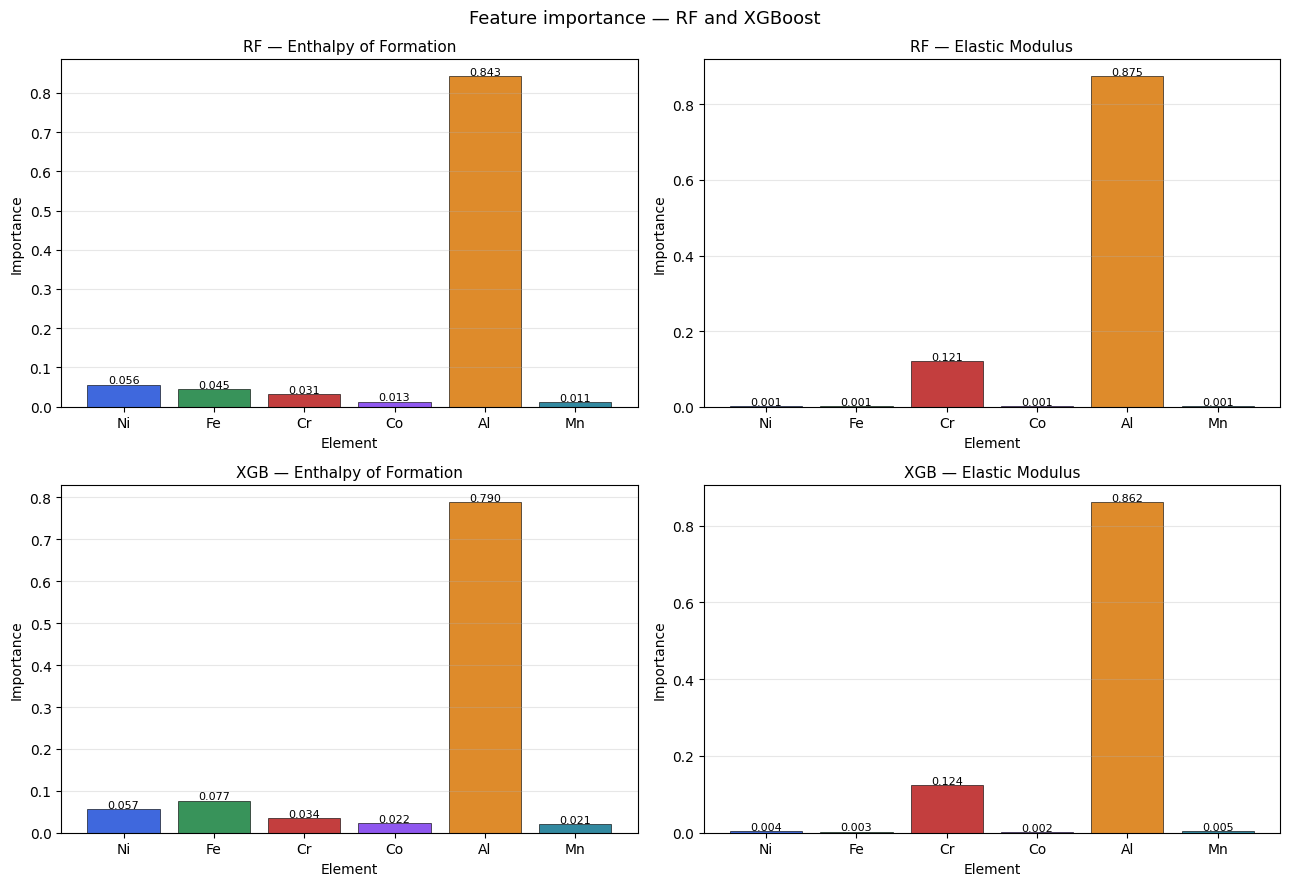

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
colors_fi = ["#1D4ED8","#15803D","#B91C1C","#7C3AED","#D97706","#0E7490"]

for ax, model, title in [
    (axes[0,0], model_rf_enth,  "RF — Enthalpy of Formation"),
    (axes[0,1], model_rf_mod,   "RF — Elastic Modulus"),
    (axes[1,0], model_xgb_enth, "XGB — Enthalpy of Formation"),
    (axes[1,1], model_xgb_mod,  "XGB — Elastic Modulus"),
]:
    imps = model.feature_importances_
    bars = ax.bar(ELEMENTS, imps, color=colors_fi, alpha=0.85, edgecolor="k", linewidth=0.5)
    ax.set_xlabel("Element"); ax.set_ylabel("Importance")
    ax.set_title(title, fontsize=11)
    ax.grid(axis="y", alpha=0.3)
    for bar, v in zip(bars, imps):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.003,
                f"{v:.3f}", ha="center", fontsize=8)

plt.suptitle("Feature importance — RF and XGBoost", fontsize=13)
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()


## 19. Save all models

In [ ]:
import pickle

models_to_save = {
    "model_lr_enth.pkl":  model_lr_enth,
    "model_lr_mod.pkl":   model_lr_mod,
    "model_rf_enth.pkl":  model_rf_enth,
    "model_rf_mod.pkl":   model_rf_mod,
    "model_xgb_enth.pkl": model_xgb_enth,
    "model_xgb_mod.pkl":  model_xgb_mod,
    "model_svr_enth.pkl": model_svr_enth,
    "model_svr_mod.pkl":  model_svr_mod,
    "model_mtl.pkl":      model_mtl,
    "scaler.pkl":         scaler,
}

for name, obj in models_to_save.items():
    with open(name, "wb") as f:
        pickle.dump(obj, f)
    print(f"Saved: {name}")

print("\nAll models saved. Upload to Google Drive or download from Colab.")


Saved: model_lr_enth.pkl
Saved: model_lr_mod.pkl
Saved: model_rf_enth.pkl
Saved: model_rf_mod.pkl
Saved: model_xgb_enth.pkl
Saved: model_xgb_mod.pkl
Saved: model_svr_enth.pkl
Saved: model_svr_mod.pkl
Saved: model_mtl.pkl
Saved: scaler.pkl

All models saved. Upload to Google Drive or download from Colab.
